# **Imports**

In [1]:
import os
import sys
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Hugging Face Imports
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding
)

# Rich UI
from rich.console import Console
from rich.panel import Panel

# XAI Imports
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from transformers_interpret import SequenceClassificationExplainer

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0417 19:26:57.338000 25708 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


# **1. Configuration & Argument Parsing**

In [17]:


def get_args():
    parser = argparse.ArgumentParser(description="DeepFashion Unified Pipeline")
    parser.add_argument('--mode', type=str, required=True, 
                        choices=[
                            'train_txt', 'train_img', 
                            'eval_img', 'eval_fusion', 
                            'img_xai', 'txt_xai'
                        ],
                        help="Select the pipeline mode to execute.")
    
    # Paths
    parser.add_argument('--root_dir', type=str, default=r'D:/Year Three/Semester Two/Principles and Design of IoT Systems/archive/selected_images')
    parser.add_argument('--csv_file', type=str, default=r'D:/Year Three/Semester Two/Principles and Design of IoT Systems/archive/labels_front.csv')
    
    # Model Selections & Weights
    parser.add_argument('--img_model', type=str, choices=['efficientnet', 'swin'], default='efficientnet')
    parser.add_argument('--txt_model', type=str, default='roberta-base')
    parser.add_argument('--img_weights', type=str, default='best_model-epoch-6.pth')
    parser.add_argument('--txt_weights_dir', type=str, default='./best_deep_fashion_model')
    
    # XAI Specific Arguments
    parser.add_argument('--image_path', type=str, default='', help="Required for img_xai mode")
    parser.add_argument('--caption', type=str, default='', help="Required for txt_xai mode")
    
    # Hyperparameters
    parser.add_argument('--batch_size', type=int, default=16)
    parser.add_argument('--accum_steps', type=int, default=1)
    parser.add_argument('--epochs', type=int, default=5)
    parser.add_argument('--num_workers', type=int, default=0)
    
    # ---------------------------------------------------------
    # JUPYTER NOTEBOOK FIX
    # ---------------------------------------------------------
    if 'ipykernel' in sys.modules:
        # You are in a Jupyter Notebook! 
        # Type the arguments you want to run as a list of strings here:
        mock_args = [
            '--mode', 'eval_fusion', 
            '--img_model', 'efficientnet',
            # Add other arguments here if needed, like: '--batch_size', '16'

            '--img_weights', 'best_model-epoch-6.pth'
        ]
        return parser.parse_args(mock_args)
    else:
        # You are in a normal terminal
        return parser.parse_args()

# **2. Data Preprocessing**

In [5]:
def get_label_encoder(csv_file):
    df = pd.read_csv(csv_file)
    le = LabelEncoder()
    le.fit(df['product_type'])
    return le, df

def get_split_indices(labels):
    indices = list(range(len(labels)))
    train_val_idx, test_idx = train_test_split(indices, test_size=0.1, stratify=labels, random_state=42)
    train_idx, val_idx = train_test_split(train_val_idx, test_size=0.1/0.9, stratify=labels[train_val_idx], random_state=42)
    return train_idx, val_idx, test_idx

class DeepFashionTransforms:
    IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

    def __init__(self, model_type):
        self.model_type = model_type
        self.img_size = 256 if model_type == 'swin' else 416
        self.crop_size = 256 if model_type == 'swin' else 380

    def train_transform(self):
    
        return transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.RandomResizedCrop(self.crop_size, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(self.IMAGENET_MEAN, self.IMAGENET_STD)
        ])

    def eval_transform(self):
        return transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.CenterCrop(self.crop_size),
            transforms.ToTensor(),
            transforms.Normalize(self.IMAGENET_MEAN, self.IMAGENET_STD)
        ])

class ImageDataset(Dataset):
    def __init__(self, root_dir, df, le, transform=None):
        self.root_dir, self.transform = root_dir, transform
        self.paths = df['path'].values
        self.labels = le.transform(df['product_type'])

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        image = Image.open(os.path.join(self.root_dir, self.paths[idx])).convert('RGB')
        return self.transform(image) if self.transform else image, self.labels[idx]

class MultimodalDataset(Dataset):
    def __init__(self, root_dir, df, le, tokenizer, img_transform=None, max_len=128):
        self.root_dir, self.transform, self.tokenizer, self.max_len = root_dir, img_transform, tokenizer, max_len
        self.paths = df['path'].values
        self.captions = df['caption'].fillna("").values
        self.labels = le.transform(df['product_type'])

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        image = Image.open(os.path.join(self.root_dir, self.paths[idx])).convert('RGB')
        if self.transform: image = self.transform(image)
        encoding = self.tokenizer(str(self.captions[idx]), padding='max_length', truncation=True, max_length=self.max_len, return_tensors='pt')
        return image, encoding['input_ids'].squeeze(0), encoding['attention_mask'].squeeze(0), self.labels[idx]

# **3. Image Model Architecture**

In [6]:
class DeepFashionImageModel(nn.Module):
    def __init__(self, model_type, num_categories):
        super().__init__()
        self.model_type = model_type
        
        if model_type == 'efficientnet':
            self.backbone = models.efficientnet_b4(weights='IMAGENET1K_V1')
            in_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
            self.classifier = nn.Sequential(
                nn.Linear(in_features, 512), nn.BatchNorm1d(512), nn.ReLU(),
                nn.Dropout(p=0.4), nn.Linear(512, num_categories)
            )
        elif model_type == 'swin':
            self.backbone = models.swin_v2_s(weights='IMAGENET1K_V1')
            in_features = self.backbone.head.in_features
            self.backbone.head = nn.Identity()
            self.classifier = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_features, num_categories))

    def forward(self, x):
        return self.classifier(self.backbone(x))

    def freeze_backbone(self):
        for param in self.backbone.parameters(): param.requires_grad = False

    def unfreeze_backbone(self):
        if self.model_type == 'efficientnet':
            for param in self.backbone.parameters(): param.requires_grad = True
        elif self.model_type == 'swin':
            for name, param in self.backbone.named_parameters():
                if 'features.6' in name or 'features.7' in name or 'norm' in name:
                    param.requires_grad = True

# **4. Training Utilities (Image Loop)**

In [7]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001, save_path='best_model.pth'):
        self.patience, self.min_delta, self.save_path = patience, min_delta, save_path
        self.counter, self.best_loss, self.early_stop = 0, float('inf'), False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.save_path)
            print(f"  Improved → saved (best loss: {self.best_loss:.4f})")
        else:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True

def run_image_epoch(model, loader, optimizer, criterion, device, scaler, accum_steps, training=True):
    model.train() if training else model.eval()
    total_loss, total_acc = 0.0, 0.0
    if training: optimizer.zero_grad()

    with torch.set_grad_enabled(training):
        loop = tqdm(loader, desc="Train" if training else "Val", leave=False)
        for i, (images, labels) in enumerate(loop):
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, labels)
                if training: loss = loss / accum_steps

            if training:
                scaler.scale(loss).backward()
                if (i + 1) % accum_steps == 0 or (i + 1) == len(loader):
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()

            total_loss += loss.item() * (accum_steps if training else 1)
            total_acc += (logits.argmax(1) == labels).float().mean().item()
            loop.set_postfix(loss=loss.item() * (accum_steps if training else 1))

    return total_loss / len(loader), total_acc / len(loader)

# **5. Mode Execution Functions (Train & Eval)**

In [8]:
def mode_train_text(args, le):
    print("\n[bold cyan]--- Training Text Model ---[/bold cyan]")
    dataset = load_dataset('csv', data_files=args.csv_file, split='train')
    dataset = dataset.add_column("labels", le.transform(dataset['product_type']))
    
    train_test_split = dataset.train_test_split(test_size=0.2, seed=42)
    dataset_dict = DatasetDict({'train': train_test_split['train'], 'val': train_test_split['test']})
    
    tokenizer = AutoTokenizer.from_pretrained(args.txt_model)
    def tokenize_function(examples): return tokenizer(examples['caption'], padding=False, truncation=True, max_length=128)
    
    tokenized_datasets = dataset_dict.map(tokenize_function, batched=True).remove_columns(["image_id", "caption", "path", "gender", "product_type", "product_id", "image_type"])
    tokenized_datasets.set_format("torch")
    
    model = AutoModelForSequenceClassification.from_pretrained(args.txt_model, num_labels=len(le.classes_))

    def compute_metrics(eval_pred):
        preds, labels = eval_pred
        return {"f1_macro": precision_recall_fscore_support(labels, np.argmax(preds, axis=1), average="macro", zero_division=0)[2]}

    training_args = TrainingArguments(
        output_dir=args.txt_weights_dir, learning_rate=2e-5, per_device_train_batch_size=args.batch_size, 
        num_train_epochs=args.epochs, eval_strategy="epoch", save_strategy="epoch", 
        metric_for_best_model="f1_macro", fp16=torch.cuda.is_available(), report_to="none"
    )

    trainer = Trainer(
        model=model, args=training_args, train_dataset=tokenized_datasets["train"], eval_dataset=tokenized_datasets["val"], 
        processing_class=tokenizer, data_collator=DataCollatorWithPadding(tokenizer=tokenizer), compute_metrics=compute_metrics
    )
    trainer.train()
    trainer.save_model(args.txt_weights_dir)
    print(f" Text model saved in '{args.txt_weights_dir}'")


def mode_train_image(args, le, df, device):
    print(f"\n--- Training Image Model: {args.img_model.upper()} ---")
    tf_handler = DeepFashionTransforms(args.img_model)
    train_idx, val_idx, _ = get_split_indices(le.transform(df['product_type']))
    
    train_loader = DataLoader(Subset(ImageDataset(args.root_dir, df, le, tf_handler.train_transform()), train_idx), batch_size=args.batch_size, shuffle=True)
    val_loader = DataLoader(Subset(ImageDataset(args.root_dir, df, le, tf_handler.eval_transform()), val_idx), batch_size=args.batch_size, shuffle=False)

    model = DeepFashionImageModel(args.img_model, len(le.classes_)).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1 if args.img_model == 'swin' else 0.0)
    scaler = torch.amp.GradScaler('cuda') if device == 'cuda' else None
    stopper = EarlyStopping(patience=5, save_path=args.img_weights)

    print("\n[Phase 1] Heads only (backbone frozen)")
    model.freeze_backbone()
    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

    for epoch in range(1, 6):
        t_loss, t_acc = run_image_epoch(model, train_loader, optimizer, criterion, device, scaler, args.accum_steps, True)
        v_loss, v_acc = run_image_epoch(model, val_loader, optimizer, criterion, device, scaler, 1, False)
        scheduler.step()
        print(f"Epoch {epoch:02d} | Val Loss: {v_loss:.4f} Acc: {v_acc:.2%}")

    print("\n[Phase 2] Gradual fine-tuning")
    if device == 'cuda': torch.cuda.empty_cache()
    model.unfreeze_backbone()
    optimizer = torch.optim.AdamW([{'params': model.backbone.parameters(), 'lr': 1e-5}, {'params': model.classifier.parameters(), 'lr': 1e-3}])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

    epoch = 0
    while not stopper.early_stop:
        epoch += 1
        t_loss, t_acc = run_image_epoch(model, train_loader, optimizer, criterion, device, scaler, args.accum_steps, True)
        v_loss, v_acc = run_image_epoch(model, val_loader, optimizer, criterion, device, scaler, 1, False)
        scheduler.step(v_loss)
        print(f"Epoch {epoch:02d} | Val Loss: {v_loss:.4f} Acc: {v_acc:.2%}")
        stopper(v_loss, model)


def mode_eval_image(args, le, df, device):
    console = Console()
    console.print(f"\n[bold cyan]--- Evaluating Image Model: {args.img_model.upper()} ---[/bold cyan]")
    
    tf_handler = DeepFashionTransforms(args.img_model)
    _, _, test_idx = get_split_indices(le.transform(df['product_type']))
    test_loader = DataLoader(
        Subset(ImageDataset(args.root_dir, df, le, tf_handler.eval_transform()), test_idx), 
        batch_size=args.batch_size, shuffle=False
    )

    model = DeepFashionImageModel(args.img_model, len(le.classes_)).to(device)
    model.load_state_dict(torch.load(args.img_weights, map_location=device))
    model.eval()

    all_preds, all_labels, all_probs = [], [], [] # Added all_probs list
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            with torch.amp.autocast('cuda'):
                logits = model(images.to(device))
                probs = F.softmax(logits, dim=1) # Get probabilities
            
            preds = logits.argmax(1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Generate Metrics & ROC Curve
    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    
    plot_multiclass_roc(all_labels, np.array(all_probs), le.classes_, f"ROC Curve - {args.img_model.upper()}", f"roc_{args.img_model}.png")
    
    result_text = f"Accuracy  : [bold green]{acc * 100:.2f}%[/bold green]\nPrecision : [bold blue]{p:.4f}[/bold blue]\nRecall    : [bold blue]{r:.4f}[/bold blue]\nF1-Score  : [bold magenta]{f1:.4f}[/bold magenta]"
    console.print(Panel(result_text, title=f"[bold yellow] OVERALL RESULTS ({args.img_model.upper()})", expand=False))


def plot_multiclass_roc(y_true, y_probs, classes, title, filename):
    """Generates and saves a Multi-Class ROC Curve plot."""
    # Binarize the labels for multi-class ROC calculation
    y_test_bin = label_binarize(y_true, classes=range(len(classes)))
    n_classes = len(classes)

    fpr, tpr, roc_auc = dict(), dict(), dict()

    # Calculate ROC curve and ROC area for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plotting
    plt.figure(figsize=(12, 9))
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC curve (area = {roc_auc["micro"]:0.2f})',
             color='deeppink', linestyle=':', linewidth=4)

    # Use a colormap to get distinct colors for the 17 classes
    colors = plt.cm.get_cmap('tab20', n_classes)
    for i, color in zip(range(n_classes), colors.colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2, alpha=0.7,
                 label=f'{classes[i]} (AUC = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontweight='bold')
    plt.ylabel('True Positive Rate', fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Put the legend outside the plot so it doesn't cover the lines
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize='small')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()
    print(f" Saved ROC Curve to: {filename}")


def mode_eval_fusion(args, le, df, device):
    console = Console()
    console.print(f"\n[bold cyan]--- Evaluating Late Fusion ({args.img_model.upper()} + {args.txt_model}) ---[/bold cyan]")
    
    tf_handler = DeepFashionTransforms(args.img_model)
    tokenizer = AutoTokenizer.from_pretrained(args.txt_weights_dir)
    _, _, test_idx = get_split_indices(le.transform(df['product_type']))
    test_loader = DataLoader(Subset(MultimodalDataset(args.root_dir, df, le, tokenizer, tf_handler.eval_transform()), test_idx), batch_size=args.batch_size)

    img_model = DeepFashionImageModel(args.img_model, len(le.classes_)).to(device)
    img_model.load_state_dict(torch.load(args.img_weights, map_location=device))
    img_model.eval()

    txt_model = AutoModelForSequenceClassification.from_pretrained(args.txt_weights_dir).to(device)
    txt_model.eval()

    all_labels, all_img_preds, all_txt_preds, all_late_preds, all_late_probs = [], [], [], [], []

    with torch.no_grad():
        for images, input_ids, attention_mask, labels in tqdm(test_loader, desc="Testing Fusion"):
            images, input_ids, attention_mask = images.to(device), input_ids.to(device), attention_mask.to(device)
            labels = labels.numpy()
            
            with torch.amp.autocast('cuda'):
                img_logits = img_model(images)
            img_probs = F.softmax(img_logits, dim=1).cpu().numpy()
            
            txt_probs = F.softmax(txt_model(input_ids=input_ids, attention_mask=attention_mask).logits, dim=1).cpu().numpy()
            
            # Calculate Late Fusion Probabilities
            late_probs = (img_probs + txt_probs) / 2.0
            
            all_late_probs.extend(late_probs)
            all_labels.extend(labels)
            all_img_preds.extend(np.argmax(img_probs, axis=1))
            all_txt_preds.extend(np.argmax(txt_probs, axis=1))
            all_late_preds.extend(np.argmax(late_probs, axis=1))

    # Calculate Multi-model Metrics
    acc = accuracy_score(all_labels, all_late_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_late_preds, average='weighted', zero_division=0)

    # Generate Fusion ROC Curve
    plot_multiclass_roc(all_labels, np.array(all_late_probs), le.classes_, "ROC Curve - Multimodal Late Fusion", "roc_late_fusion.png")

    # Final Comparison Prints (Now safely back inside the evaluation function!)
    print("\n" + "=" * 60)
    print("  FINAL COMPARISON — TEST SET ACCURACY")
    print("=" * 60)
    print(f"  Image-only ({args.img_model.capitalize()})  — Test Acc: {accuracy_score(all_labels, all_img_preds):.4f}")
    print(f"  Text-only (DeBERTa)        — Test Acc: {accuracy_score(all_labels, all_txt_preds):.4f}")
    print(f"  Late Fusion (Average)      — Test Acc: {acc:.4f}")
    print("=" * 60)

    # Print Detailed Fusion Metrics
    result_text = f"Accuracy  : [bold green]{acc * 100:.2f}%[/bold green]\nPrecision : [bold blue]{p:.4f}[/bold blue]\nRecall    : [bold blue]{r:.4f}[/bold blue]\nF1-Score  : [bold magenta]{f1:.4f}[/bold magenta]"
    console.print(Panel(result_text, title=f"[bold yellow] LATE FUSION METRICS", expand=False))

# **6. Mode Execution Functions (XAI)**

In [9]:
def mode_img_xai(args, le, device):
    print(f"\n--- Generating Grad-CAM for {os.path.basename(args.image_path)} ---")
    tf_handler = DeepFashionTransforms(args.img_model)
    
    img_model = DeepFashionImageModel(args.img_model, len(le.classes_)).to(device)
    img_model.load_state_dict(torch.load(args.img_weights, map_location=device))
    img_model.eval()

    raw_img = cv2.resize(cv2.cvtColor(cv2.imread(args.image_path), cv2.COLOR_BGR2RGB), (tf_handler.crop_size, tf_handler.crop_size))
    input_tensor = tf_handler.eval_transform()(Image.open(args.image_path).convert('RGB')).unsqueeze(0).to(device)

    cam = GradCAM(model=img_model, target_layers=[img_model.backbone.features[-1]])
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    cam_image = show_cam_on_image(np.float32(raw_img) / 255.0, grayscale_cam, use_rgb=True)

    out_path = f"gradcam_{args.img_model}.jpg"
    cv2.imwrite(out_path, cv2.cvtColor(cam_image, cv2.COLOR_RGB2BGR))
    print(f" Saved Image XAI to: {out_path}")

def mode_txt_xai(args, device):
    print(f"\n--- Generating Text XAI ---")
    tokenizer = AutoTokenizer.from_pretrained(args.txt_weights_dir)
    txt_model = AutoModelForSequenceClassification.from_pretrained(args.txt_weights_dir).to(device)
    
    explainer = SequenceClassificationExplainer(txt_model, tokenizer)
    word_attributions = explainer(args.caption)
    
    print(f"\nPredicted Category: {explainer.predicted_class_name}\n" + "-"*30)
    clean_words, clean_scores = [], []
    for word, score in word_attributions:
        if word not in ['[CLS]', '[SEP]', '<pad>', '<s>', '</s>'] and word.replace('Ġ', '').strip():
            clean_words.append(word.replace('Ġ', ''))
            clean_scores.append(score)
            color = "\033[92m" if score > 0 else "\033[91m"
            print(f"  {color}{clean_words[-1]}: {score:.4f}\033[0m")

    # Generate Chart
    fig, ax = plt.subplots(figsize=(8, max(4, len(clean_words) * 0.4)))
    colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in clean_scores] 
    ax.barh(range(len(clean_words)), clean_scores, color=colors)
    ax.set_yticks(range(len(clean_words)))
    ax.set_yticklabels(clean_words, fontsize=11)
    ax.set_title(f"Text XAI Attributions\nPredicted: {explainer.predicted_class_name}", fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("text_xai_plot.png", dpi=300)
    plt.close()
    
    explainer.visualize("text_xai_output.html")
    print(f" Saved HTML visual report and PNG Bar Chart.")

# **7. Main Router**

In [18]:
if __name__ == '__main__':
    print("--- Environment Check ---")
    print(f"Python: {sys.executable}")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device: {device}\n" + "-" * 25)

    args = get_args()
    le, df = get_label_encoder(args.csv_file)

    if args.mode == 'train_txt':       mode_train_text(args, le)
    elif args.mode == 'train_img':     mode_train_image(args, le, df, device)
    elif args.mode == 'eval_img':      mode_eval_image(args, le, df, device) 
    elif args.mode == 'eval_fusion':   mode_eval_fusion(args, le, df, device)
    elif args.mode == 'img_xai':       mode_img_xai(args, le, device)
    elif args.mode == 'txt_xai':       mode_txt_xai(args, device)

--- Environment Check ---
Python: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
Device: cuda
-------------------------


--- Evaluating Late Fusion (EFFICIENTNET + roberta-base) ---

Testing Fusion: 100%|██████████| 77/77 [01:08<00:00,  1.12it/s]
C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_25708\1961161878.py:138: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', n_classes)


 Saved ROC Curve to: roc_late_fusion.png

  FINAL COMPARISON — TEST SET ACCURACY
  Image-only (Efficientnet)  — Test Acc: 0.7638
  Text-only (DeBERTa)        — Test Acc: 0.6767
  Late Fusion (Average)      — Test Acc: 0.7956


╭─  LATE FUSION METRICS ─╮
│ Accuracy  : 79.56%     │
│ Precision : 0.8001     │
│ Recall    : 0.7956     │
│ F1-Score  : 0.7923     │
╰────────────────────────╯

# **8. Train Text**

In [ ]:
!python Late-Fusion-Model.py --mode train_txt --batch_size 16 --epochs 5

# **9. Train Image (EfficientNet)**

In [ ]:
!python Late-Fusion-Model.py --mode train_img --img_model efficientnet --batch_size 16

# **10. Train Image (Swin Transformer)**

In [ ]:
!python Late-Fusion-Model.py --mode train_img --img_model swin --batch_size 16 --accum_steps 4

# **11. Multimodel Evaluation**

In [ ]:
!python Late-Fusion-Model.py --mode eval_fusion --img_model efficientnet --img_weights best_model-epoch-6.pth --txt_weights_dir ./best_deep_fashion_model

# **12. XAI For Imgaes**

In [ ]:
!python Late-Fusion-Model.py --mode img_xai --img_model efficientnet --img_weights best_model-epoch-6.pth --image_path "D:/Year Three/Semester Two/Principles and Design of IoT Systems/archive/selected_images/test_image.jpg"

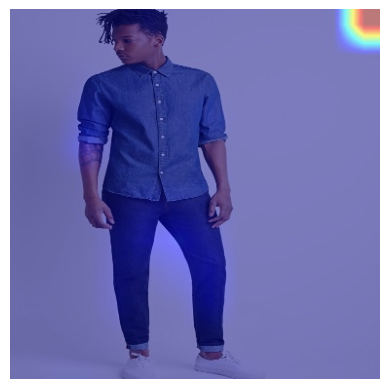

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image


img = Image.open('gradcam_output2.jpg')

# Display the image
plt.imshow(img)
plt.axis('off') 
plt.show()

# **12. XAI For Text**

In [ ]:
!python Late-Fusion-Model.py --mode txt_xai --caption "A casual distressed blue denim jacket with silver buttons."

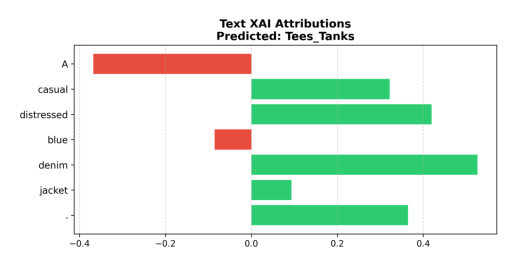

In [20]:
img = Image.open('text_xai_plot2.png')

# Display the image
plt.imshow(img)
plt.axis('off') 
plt.show()